# 1. Loading the libraries required for the project

In [ ]:
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 2. Data loading

The following dataset was used: https://www.kaggle.com/datasets/eshummalik/insta-trends-turning-data-into-virality/data 

This dataset contains 119 Instagram posts along with their engagement metrics, such as likes, comments, shares, saves, profile visits, and new followers. Each post also includes the caption and hashtags, providing a comprehensive view of content performance.

In [ ]:
path = kagglehub.dataset_download(
    "eshummalik/insta-trends-turning-data-into-virality"
)

csv_files = [f for f in os.listdir(path) if f.endswith(".csv")]
csv_path = os.path.join(path, csv_files[0])

try:
    df = pd.read_csv(csv_path, encoding="utf-8")
except UnicodeDecodeError:
    df = pd.read_csv(csv_path, encoding="latin1")

df.columns = df.columns.str.strip().str.lower()


# 3. Data exploration

According to the dataset description, the data is clean. We check for missing values and also review the data types of each column.

In [ ]:
df.info()
missing_values = df.isnull().sum()
print('Missing values in each column:')
print(missing_values)

# 4. EDA - Exploratory Data Analysis

EDA (Exploratory Data Analysis) is the process in which we:

- examine the data
- check the structure of the columns
- look for patterns and relationships
- detect errors, missing values, and outliers
- generate initial insights and observations

The goal is to understand the data before building models, making predictions, or drawing conclusions.

# 4.1. Likes distribution

We observe that the distribution of likes is right-skewed — the peak is on the left, with a long tail extending to the right. Most posts receive up to 200–300 likes, while a small number generate a very high number of likes.

This is typical for social media platforms, where such posts are often referred to as “viral” content.

In [ ]:
df.columns = df.columns.str.strip().str.lower()
likes_col = [c for c in df.columns if "like" in c][0]
likes = pd.to_numeric(df[likes_col], errors="coerce")

bins = np.linspace(likes.min(), likes.max(), 20)
plt.figure(figsize=(9, 5))
plt.hist(
    likes,
    bins=bins,
    edgecolor="black"
)

plt.xlabel("Number of Likes")
plt.ylabel("Number of Posts")
plt.title("Distribution of Likes Across Posts")

plt.tight_layout()
plt.show()

# 4.2. Comments distribution

We can draw a similar conclusion for the distribution of comments. Here as well, we observe a right-skewed distribution. Most posts have between 4 and 9 comments, with the most common range being around 5–7 comments.

We also see the presence of outliers — posts with a significantly higher number of comments compared to the average.

Again, this highlights the uneven nature of user engagement distribution in social media data.

In [ ]:
com_col = [c for c in df.columns if "comment" in c][0]
comments = pd.to_numeric(df[com_col], errors="coerce")

bins = np.linspace(comments.min(), comments.max(), 20)
plt.figure(figsize=(9, 5))
plt.hist(
    comments,
    bins=bins,
    edgecolor="black"
)

plt.xlabel("Number of Comments")
plt.ylabel("Number of Posts")
plt.title("Distribution of Comments Across Posts")

plt.tight_layout()
plt.show()

# 4.3. Caption length distribution 

We continue with content analysis. The dataset includes the caption text for each post. We add a new column to store the length of each caption.

Regarding caption length, we most commonly observe descriptions of up to 100 characters.

In [ ]:
caption_col = [c for c in df.columns if "caption" in c][0]

df["caption_length"] = df[caption_col].astype(str).apply(len)

bins = np.linspace(df["caption_length"].min(), df["caption_length"].max(), 15)

plt.figure(figsize=(9, 5))
plt.hist(df["caption_length"], bins=bins, edgecolor="black")

plt.xlabel("Caption Length (characters)")
plt.ylabel("Number of Posts")
plt.title("Distribution of Caption Length")
plt.tight_layout()
plt.show()

# 4.4. Likes vs Caption length

We create a scatter plot to explore whether there is any relationship between the number of likes and the caption length.

In [ ]:
likes_col = [c for c in df.columns if "like" in c][0]
df[likes_col] = pd.to_numeric(df[likes_col], errors="coerce")

plot_df = df.dropna(subset=[likes_col, "caption_length"])

plt.figure(figsize=(9, 5))

plt.scatter(
    plot_df["caption_length"],
    plot_df[likes_col],
    alpha=0.6
)

z = np.polyfit(plot_df["caption_length"], plot_df[likes_col], 1)
p = np.poly1d(z)

x_vals = np.linspace(
    plot_df["caption_length"].min(),
    plot_df["caption_length"].max(),
    100
)

plt.plot(x_vals, p(x_vals), linewidth=2)

plt.xlabel("Caption Length (characters)")
plt.ylabel("Likes")
plt.title("Likes vs Caption Length")
plt.tight_layout()
plt.show()

There is no strong relationship between caption length and likes. The plot shows a weak negative correlation between caption length and the number of likes.

Although a slight downward trend can be observed, the data is highly scattered, indicating that caption length alone is not a sufficient factor for predicting engagement.

We also observe individual posts with short captions and high numbers of likes, suggesting that additional factors beyond the ones analyzed are influencing performance.

# 4.5. Engagement score

To measure engagement, a composite metric is used that combines the number of likes and comments, with comments assigned a higher weight due to their stronger level of user interaction.

In [ ]:
df["engagement_score"] = df["likes"] + 2 * df["comments"]

eng = df["engagement_score"].dropna()

bins = np.linspace(eng.min(), eng.max(), 20)

plt.figure(figsize=(9, 5))
plt.hist(eng, bins=bins, edgecolor="black")

plt.xlabel("Engagement Score")
plt.ylabel("Number of Posts")
plt.title("Distribution of Engagement Score")
plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(6, 4))
plt.boxplot(eng, vert=True)

plt.ylabel("Engagement Score")
plt.title("Boxplot of Engagement Score")
plt.tight_layout()
plt.show()

The boxplot analysis shows that the engagement score has a right-skewed distribution. Most posts cluster around the median, while a small number of posts exhibit significantly higher engagement and appear as outliers.

This suggests that engagement is unevenly distributed and supports the use of models that are robust to outliers.

# 4.6. Correlation matrix

To select the features for the model we are going to build, we use a correlation matrix that describes the relationships between all variables in the dataset.

Instead of using the caption and hashtag text columns directly, we use newly engineered features such as caption length and the number of hashtags per post.

In [ ]:
hashtag_col = [c for c in df.columns if "hashtag" in c and c.startswith("has")][0]

numeric_df = df.select_dtypes(include=[np.number])

numeric_df["hashtag_count"] = df[hashtag_col].astype(str).str.count("#")
numeric_df["caption_length"] = df[caption_col].astype(str).apply(len)
df["hashtag_count"] = numeric_df["hashtag_count"]

corr = numeric_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')


# 4.7. Top 20

We select the top 20 most liked posts.

In [ ]:
top20 = df.sort_values(by=likes_col, ascending=False).head(20)

plt.figure(figsize=(10, 5))
plt.bar(range(len(top20)), top20[likes_col])
plt.xticks(range(len(top20)), range(1, 21))
plt.xlabel("Top 20 Posts")
plt.ylabel("Likes")
plt.title("Top 20 Posts by Likes")
plt.tight_layout()
plt.show()

And the 20 posts with the fewest likes.

In [ ]:
bottom20 = df.sort_values(by=likes_col, ascending=True).head(20)

plt.figure(figsize=(10, 5))
plt.bar(range(len(bottom20)), bottom20[likes_col])
plt.xticks(range(len(bottom20)), range(1, 21))
plt.xlabel("Bottom 20 Posts")
plt.ylabel("Likes")
plt.title("Bottom 20 Posts by Likes")
plt.tight_layout()
plt.show()

For both categories, we compare the number of hashtags and the caption length.

In [ ]:
top20_table = top20[
    [likes_col, "hashtag_count", "caption_length"]
].copy()

top20_table.columns = [
    "Likes",
    "Hashtags Count",
    "Caption Length"
]

top20_table.insert(0, "Rank", range(1, 21))

top20_table

In [ ]:
bottom20_table = bottom20[
    [likes_col, "hashtag_count", "caption_length"]
].copy()

bottom20_table.columns = [
    "Likes",
    "Hashtags Count",
    "Caption Length"
]

bottom20_table.insert(0, "Rank", range(1, 21))

bottom20_table

# 5. Data modelling

To model engagement, a regression approach is used, based solely on content-related features — caption length and number of hashtags.

Mean Absolute Error:
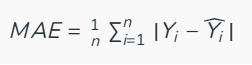

Coefficient of Determination
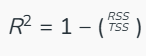

Residual sum of Squares
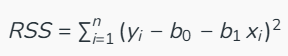

Total Sum of Squares
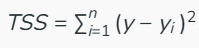

In [ ]:
model_df = df[
    ["caption_length", "hashtag_count", "engagement_score"]
].dropna()
X = model_df[["caption_length", "hashtag_count"]]
y = model_df["engagement_score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

plt.figure(figsize=(8, 5))

plt.scatter(
    X_train["caption_length"],
    y_train,
    label="Train",
    alpha=0.7
)

plt.scatter(
    X_test["caption_length"],
    y_test,
    label="Test",
    alpha=0.7
)

plt.xlabel("Caption Length")
plt.ylabel("Engagement Score")
plt.title("Caption Length vs Engagement (Train vs Test)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X_train["hashtag_count"],
    y_train,
    label="Train",
    alpha=0.7
)

plt.scatter(
    X_test["hashtag_count"],
    y_test,
    label="Test",
    alpha=0.7
)

plt.xlabel("Hashtags Count")
plt.ylabel("Engagement Score")
plt.title("Hashtags Count vs Engagement (Train vs Test)")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

coeffs = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coeffs

In [ ]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.7)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linewidth=2)

plt.xlabel("Actual Engagement Score")
plt.ylabel("Predicted Engagement Score")
plt.title("Actual vs Predicted Engagement (Linear Regression)")
plt.tight_layout()
plt.show()

Although linear regression is used as a baseline model, visual analysis of the data shows no clear linear relationship between the selected features and engagement.

Therefore, nonlinear models are also considered, as they are more suitable for capturing complex patterns in the data.

In [ ]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=5,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("R²:", r2_score(y_test, y_pred_rf))

In [ ]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.7)

min_val = min(y_test.min(), y_pred_rf.min())
max_val = max(y_test.max(), y_pred_rf.max())
plt.plot([min_val, max_val], [min_val, max_val], linewidth=2)

plt.xlabel("Actual Engagement Score")
plt.ylabel("Predicted Engagement Score")
plt.title("Actual vs Predicted Engagement (Random Forest)")
plt.tight_layout()
plt.show()

In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance

Log-transform of the engagement score


In [ ]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

rf_log = RandomForestRegressor(
    n_estimators=300,
    min_samples_leaf=5,
    random_state=42
)

rf_log.fit(X_train, y_train_log)
y_pred_log = rf_log.predict(X_test)

print("Random Forest (log target) - log scale")
print("MAE:", mean_absolute_error(y_test_log, y_pred_log))
print("R²:", r2_score(y_test_log, y_pred_log))

y_pred_log_back = np.expm1(y_pred_log)

print("\nRandom Forest (log target) - original scale")
print("MAE:", mean_absolute_error(y_test, y_pred_log_back))
print("R²:", r2_score(y_test, y_pred_log_back))


In [ ]:
eng = model_df["engagement_score"].dropna()
log_eng = np.log1p(eng)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(eng, bins=20, edgecolor="black")
axes[0].set_title("Engagement Score (Original)")
axes[0].set_xlabel("Engagement Score")
axes[0].set_ylabel("Number of Posts")

axes[1].hist(log_eng, bins=20, edgecolor="black")
axes[1].set_title("Engagement Score (Log-transformed)")
axes[1].set_xlabel("log(Engagement Score + 1)")
axes[1].set_ylabel("Number of Posts")

plt.tight_layout()
plt.show()

The plots show that the initial distribution of the engagement score is strongly right-skewed with the presence of outliers. After applying a logarithmic transformation, the distribution becomes more symmetric with more stable variance, which justifies its use to improve model training.

In [ ]:
r2_linear = r2_score(y_test, y_pred)
r2_rf = r2_score(y_test, y_pred_rf)
r2_rf_log = r2_score(y_test, y_pred_log_back)

models = [
    "Linear Regression",
    "Random Forest",
    "Random Forest (log target)"
]

r2_values = [r2_linear, r2_rf, r2_rf_log]

plt.figure(figsize=(8, 5))
plt.bar(models, r2_values, edgecolor="black")
plt.ylabel("R² Score")
plt.title("R² Comparison Between Models (Original Scale)")
plt.xticks(rotation=15)
plt.ylim(min(r2_values) - 0.1, max(r2_values) + 0.1)
plt.tight_layout()
plt.show()


The comparison of models shows that linear regression has limited explanatory power, which is expected given the lack of a clear linear relationship between the selected features and engagement.

The nonlinear Random Forest model achieves a significantly higher coefficient of determination, confirming the presence of more complex relationships in the data.

Applying a logarithmic transformation to the target variable leads to more stable model behavior, but results in a lower R² value when evaluated on the original scale.

In [ ]:
mae_linear = mean_absolute_error(y_test, y_pred)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mae_rf_log = mean_absolute_error(y_test, y_pred_log_back)

models = [
    "Linear Regression",
    "Random Forest",
    "Random Forest (log target)"
]

mae_values = [mae_linear, mae_rf, mae_rf_log]

plt.figure(figsize=(8, 5))
plt.bar(models, mae_values, edgecolor="black")
plt.ylabel("Mean Absolute Error (MAE)")
plt.title("MAE Comparison Between Models (Original Scale)")
plt.xticks(rotation=15)
plt.ylim(0, max(mae_values) * 1.1)
plt.tight_layout()
plt.show()


The comparison based on MAE shows that the nonlinear Random Forest model achieves the lowest mean absolute error, making it the most accurate model for predicting the engagement score.

Linear regression demonstrates a significantly higher error, while the model with a logarithmically transformed target variable offers more stable behavior at the cost of a slightly higher error on the original scale.

In [ ]:
sample = pd.DataFrame({
    "caption_length": [120],
    "hashtag_count": [5]
})

pred_linear = model.predict(sample)

pred_rf = rf.predict(sample)

pred_rf_log = rf_log.predict(sample)
pred_rf_log_back = np.expm1(pred_rf_log)

predictions = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Random Forest (log target)"
    ],
    "Predicted Engagement Score": [
        pred_linear[0],
        pred_rf[0],
        pred_rf_log_back[0]
    ]
})

predictions


# 6. Data exporting

In [ ]:
df.to_csv("/kaggle/working/instagram_export.csv", index=False)